# Isolated students

Can you spot first-year students who are not part of any group of fellow students, without asking anyone?

Universities (should) care if first-year students fit in socially, since isolation is a likely cause to dropping out.


## Setup

In [6]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import NearestNeighbors
import preprocess as pp
import friends as fr
import isolated as iso


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
bt = pp.load_bt()
prox = pp.proximity()
st = pp.student_table()
fb = pp.clean_fb(pp.load_fb())


In [8]:
# parameters, change and rerun from here
rssi = -80
min_coverage = 0.5
k = 20 # neighbours for LOF
top_share = 0.05 # share of students to flag


## One row per student

Each student gets two numbers from the proximity data. "Together" means the same as in `friends`: a signal of -80 dBm or stronger outside of teaching hours. In a lecture the schedule decides who is near, so teaching hours don't say much about groups. `friends` shows this: of the pairs near each other at least once in class, 9.2% are Facebook friends, against 15.1% outside class.

| Feature | What it is |
|---|---|
| `company` | share of the hours outside class, with the phone on, when anyone was near |
| `partners` | number of different students near during the 28 days |

Only students with a coverage of 50% or more are used. A phone that is switched off looks the same as a student who is alone, so the other students are "not observed", not isolated. For the same reason, `company` counts only hours when the phone was on.

Facebook, calls and SMS are not used here. They are used later to check the result, and that check is only fair if the method never saw them.


In [9]:
observed = iso.observed_hours(bt)
# SELECT user FROM st WHERE coverage >= min_coverage
ids = st.index[st.coverage >= min_coverage]
f = iso.features(fr.together(prox, rssi), observed, ids)
print(f"{(st.coverage > 0).sum()} students with bluetooth data, {len(ids)} with coverage of {min_coverage:.0%} or more")
f.describe().round(3)


706 students with bluetooth data, 615 with coverage of 50% or more


,company,partners
count,615.000,615.000
mean,0.185,36.763
std,0.217,35.310
min,0.000,0.000
25%,0.031,11.000
50%,0.093,26.000
75%,0.245,50.000
max,0.925,181.000


## Never with anyone

Some students had their phone on at least half of the time but were never near other students outside of class. They are the clearest answer to the question.

They have the same values so to LOF they're a dense group and each of them gets the score 1.0, which means normal. scikit-learn also warns about this. The course calls it masking: anomalies that are close together hide each other. So these students are reported here, and LOF only gets the students who were near someone at least once.


In [10]:
# SELECT user FROM f WHERE company = 0
never = f.index[f.company == 0]
print(f"{len(never)} students never near another student outside class")
# lof with these students included, no log since log10(0) is not defined
# SELECT DISTINCT ROUND(lof, 3) FROM lof(f) WHERE user IN never
print("their LOF scores:", iso.lof(iso.scale(f, log=False), k)[never].round(3).unique())


23 students never near another student outside class
their LOF scores: [1.]


/home/tobias/skola/uu/dm1/data-mining-1/.venv/lib/python3.10/site-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


## Scaling

LOF (local outlier factor) measures Euclidean distance, so both features (company, partners) need the same scale. Both have long right tails as most students have little company and few partners, and a few have a lot. On a normal scale those few highly social students are far from everyone else, thus we expect LOF to flag them instead of the "isolated" ones. A log10 scale spreads out the low end, so 1, 10 and 100 partners become 0, 1 and 2. After the log, each feature becomes a z-score (mean 0, standard deviation 1). We will also run LOF without the log to test this.

The two features are 0.62 correlated after the log. They measure different things, how much time and with how many people, so both are kept.


In [11]:
# students near someone at least once
d = f[f.company > 0]
print("skew before log:", d.skew().round(1).to_dict())
print("skew after log:", np.log10(d).skew().round(1).to_dict())
# SELECT CORR(LOG10(company), LOG10(partners)) FROM d
print(f"correlation after log: {np.log10(d).corr().iloc[0, 1]:.2f}")


skew before log: {'company': 1.4, 'partners': 1.5}
skew after log: {'company': -0.4, 'partners': -0.7}
correlation after log: 0.62


## LOF

LOF compares how dense the area around a student is with how dense the areas around their k = 20 nearest neighbours are. A score near 1 means normal. A higher score means the student is in a sparser area than their neighbours.

    k = 20 is the scikit-learn default, and k should be larger than any group of isolated students, or the group looks like a normal dense area.

LOF fits this question because there's no list of isolated students to learn from and the features are skewed. So methods that assume a normal distribution do not fit, and an isolated student should be far from the others in both features.

The top 5% (30 students) are flagged. LOF also flags students who are unusual in a social way, so only the flagged students with less company than the median student count as isolated.


LOF median 1.02, top 30 of 592 from 1.27, highest 2.27
21 of the top 30 have less company than the median student
17 students with 1 or 2 partners and company below 1%, 7 of them in the top 30


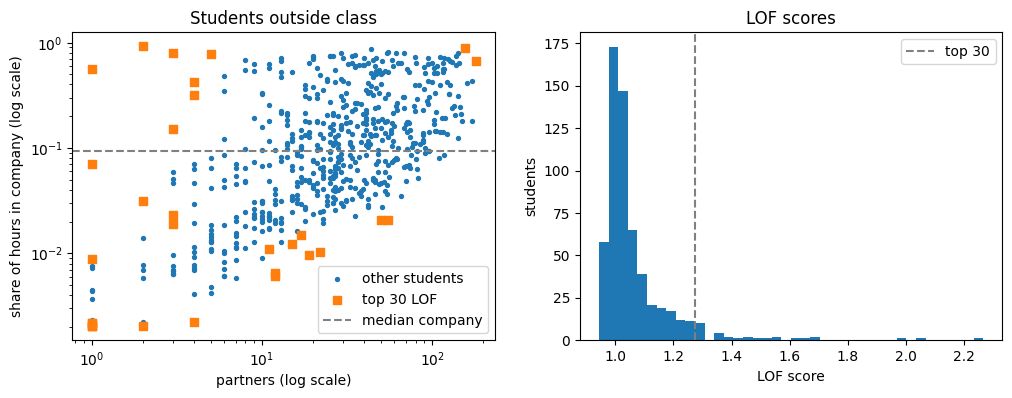

In [12]:
X = iso.scale(d)
s = iso.lof(X, k)
n = round(top_share * len(s))
# SELECT user FROM s ORDER BY lof DESC LIMIT n
top = s.nlargest(n).index
# SELECT user, company < (SELECT MEDIAN(company) FROM f) AS alone FROM f
alone = f.company < f.company.median()
# SELECT user FROM top JOIN alone USING (user) WHERE alone
flagged = top[alone[top]]
# SELECT user FROM d WHERE partners <= 2 AND company < 0.01
corner = d.index[(d.partners <= 2) & (d.company < 0.01)]
print(f"LOF median {s.median():.2f}, top {n} of {len(s)} from {s[top].min():.2f}, highest {s.max():.2f}")
print(f"{len(flagged)} of the top {n} have less company than the median student")
print(f"{len(corner)} students with 1 or 2 partners and company below 1%, {len(corner.intersection(top))} of them in the top {n}")
fig = iso.plot_lof(d, s, top, f.company.median())


21 of the 30 flagged students have less company than the median.

The scores have no clear gap (right plot). Most students have LOF close to 1, and LOF increase slowly. So the top 5% choice of how many students to report is not a border in the data.

The lower left corner (left plot) show where LOF is weak. 17 students have one or two partners and company below 1%. They sit close together so to LOF that area is dense, thus only 7 of them reach the top 5%.
